In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Miért van szükség az adatok ábrázolására?
Példa: Anscombe kvartett

(Francis Anscombe, 1973).

In [5]:
anscombe = sns.load_dataset('anscombe')

In [6]:
type(anscombe)

pandas.core.frame.DataFrame

Alapvető információk

In [7]:
anscombe.columns

Index(['dataset', 'x', 'y'], dtype='object')

In [8]:
anscombe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  44 non-null     object 
 1   x        44 non-null     float64
 2   y        44 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.2+ KB


In [9]:
anscombe.describe().T

,count,mean,std,min,25%,50%,75%,max
x,44.0,9.000000,3.198837,4.0,7.0000,8.00,11.0000,19.00
y,44.0,7.500682,1.958925,3.1,6.1175,7.52,8.7475,12.74


In [10]:
anscombe.groupby('dataset').size()

dataset
I      11
II     11
III    11
IV     11
dtype: int64

Határozzuk meg az átlagot és a szórást a négy adathalmazra!

In [11]:
anscombe.groupby('dataset').mean()

,x,y
dataset,,
I,9.0,7.500909
II,9.0,7.500909
III,9.0,7.500000
IV,9.0,7.500909


In [12]:
anscombe.groupby('dataset').std()

,x,y
dataset,,
I,3.316625,2.031568
II,3.316625,2.031657
III,3.316625,2.030424
IV,3.316625,2.030579


In [16]:
# vagy egyben:
anscombe.groupby('dataset').agg( ['mean', 'std']).T

dataset         I        II       III        IV
x mean   9.000000  9.000000  9.000000  9.000000
  std    3.316625  3.316625  3.316625  3.316625
y mean   7.500909  7.500909  7.500000  7.500909
  std    2.031568  2.031657  2.030424  2.030579

Határozzuk meg a korrelációs együtthatót az adathalmazokra!

In [19]:
anscombe.groupby('dataset').corr().T

dataset         I                  II                 III                  IV  \
                x         y         x         y         x         y         x   
x        1.000000  0.816421  1.000000  0.816237  1.000000  0.816287  1.000000   
y        0.816421  1.000000  0.816237  1.000000  0.816287  1.000000  0.816521   

dataset            
                y  
x        0.816521  
y        1.000000

És most nézzük meg az adatokat ábrázolva:

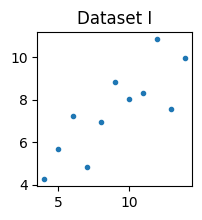

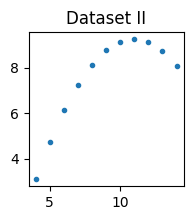

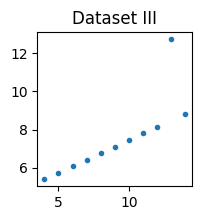

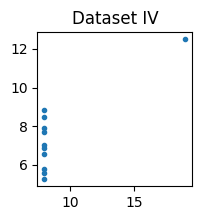

In [ ]:
for item in anscombe['dataset'].unique(): # Visszaadja a 4 csoport nevét
    x = anscombe[ anscombe['dataset'] == item ]['x'] # Szűrés csoport neve szerint
    y = anscombe[ anscombe['dataset'] == item ]['y']
    plt.figure(figsize=(2,2)) # 2x2 hüvelyk méretű vászon
    plt.plot(x,y,'.') # x és y adatok, majd ne legyenek összekötő vonalak
    plt.title('Dataset %s' %item) #  Az %s helyére be lesz helyettesítve az aktuális dataset
    plt.show()

Egy másik példa: Datasaurus

Kezdjük egy egyszerű vonaldiagrammal:

In [ ]:
# generáljunk adatokat
x = np.arange(20) # 0-tól 19-ig egész számok
y = np.random.rand(20) # 20 db véletlen szám 0 és 1 között

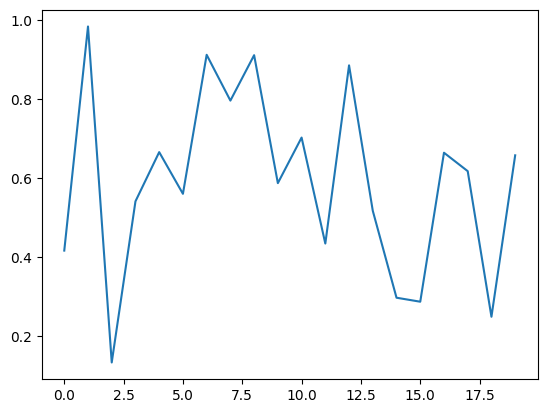

In [27]:
# az első ábra
plt.plot(x,y)
plt.show()

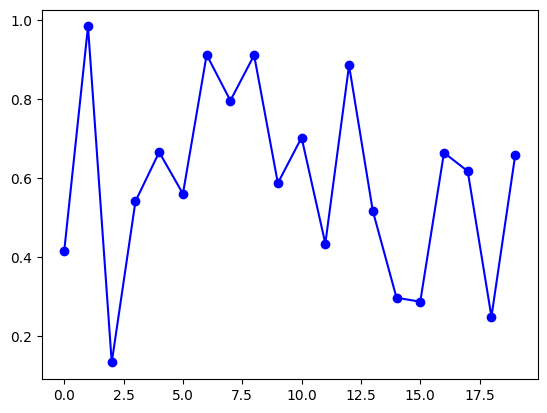

In [30]:
# marker, vonal, szín:
plt.plot(x,y, 'o-b') # marker, vonal, kék
plt.show()

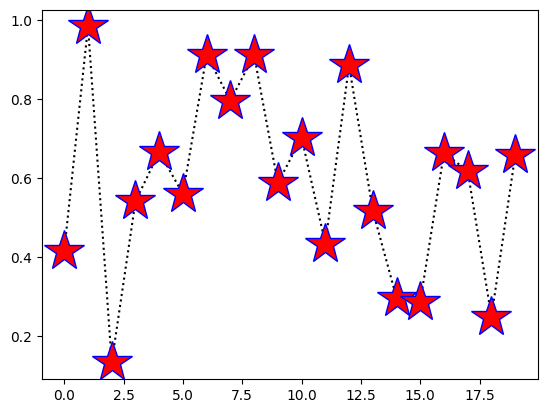

In [43]:
# marker stílus, szín, méret:
# ms: marker size
# mec: marker edge color
# mfc: marker face color

plt.plot(x,y,'k:', marker = '*', ms = 30, mec = 'b', mfc = 'r')
# blacK szaggatott vonal (:), csillag/o/+/. marker size, 
plt.show()

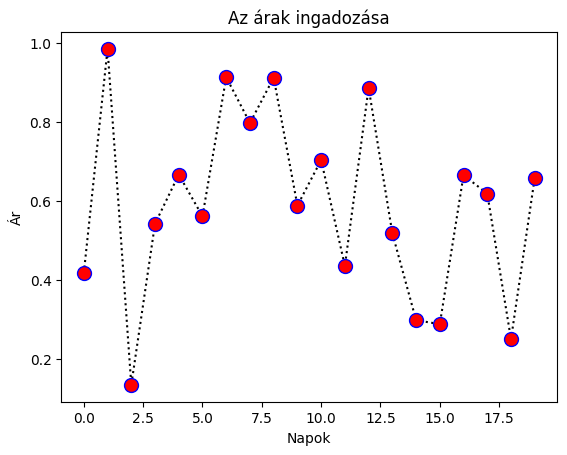

In [44]:
# Adjunk neki címet, feliratokat a tengelyekre:
plt.plot(x,y,'k:', marker = 'o', ms = 10, mec = 'b', mfc = 'r')
plt.title('Az árak ingadozása')
plt.xlabel('Napok')
plt.ylabel('Ár')
plt.show()

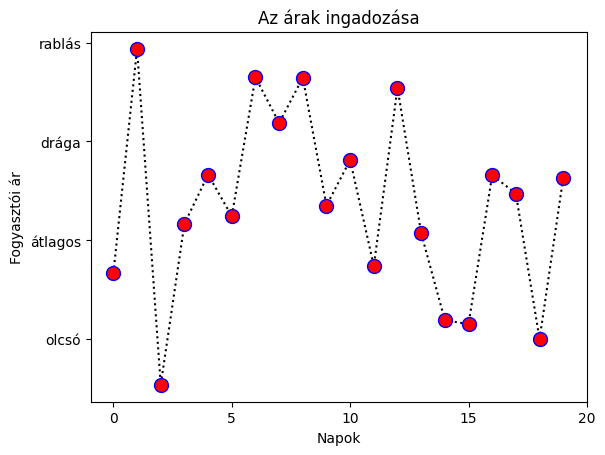

In [ ]:
# Adjuk meg a tengelyek fontosabb értékeit, feliratokkal:
plt.plot(x,y,'k:', marker = 'o', ms = 10, mec = 'b', mfc = 'r')
plt.title('Az árak ingadozása')
plt.xlabel('Napok')
plt.ylabel('Fogyasztói ár')
plt.xticks([0,5,10,15,20]) # tengelyértékek
plt.yticks([0.25, 0.5, 0.75, 1], ['olcsó', 'átlagos','drága', 'rablás']) # trengelyértékek elnevezéssel
plt.show()

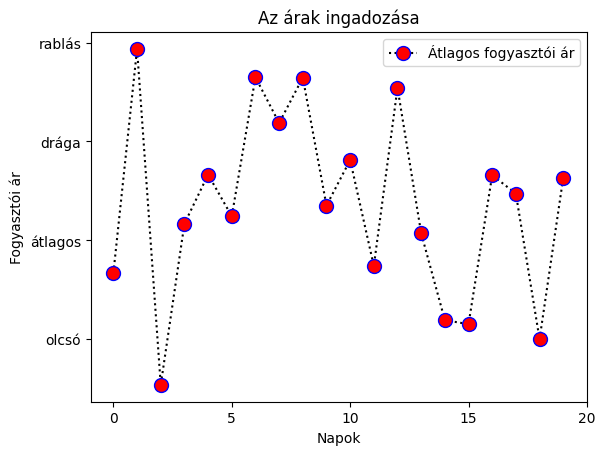

In [ ]:
# Adjunk magyarázó szöveget az ábrához:
plt.plot(x,y,'k:', marker = 'o', ms = 10, mec = 'b', mfc = 'r', label='Átlagos fogyasztói ár')
plt.title('Az árak ingadozása')
plt.xlabel('Napok')
plt.ylabel('Fogyasztói ár')
plt.xticks([0,5,10,15,20])
plt.yticks([0.25, 0.5, 0.75, 1], ['olcsó', 'átlagos','drága', 'rablás'])
plt.legend(loc='upper right') # magyarázó
plt.show()

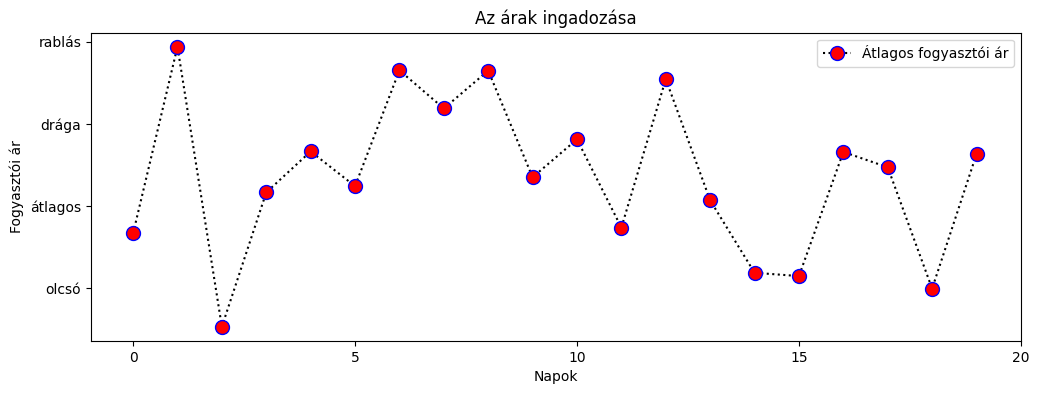

In [ ]:
# méretezzük át:
plt.figure(figsize=(12,4)) # méret hüvelykben
plt.plot(x,y,'k:', marker = 'o', ms = 10, mec = 'b', mfc = 'r', label='Átlagos fogyasztói ár')
plt.title('Az árak ingadozása')
plt.xlabel('Napok')
plt.ylabel('Fogyasztói ár')
plt.xticks([0,5,10,15,20])
plt.yticks([0.25, 0.5, 0.75, 1], ['olcsó', 'átlagos','drága', 'rablás'])
plt.legend(loc='upper right')
plt.show()

Subplot-ok

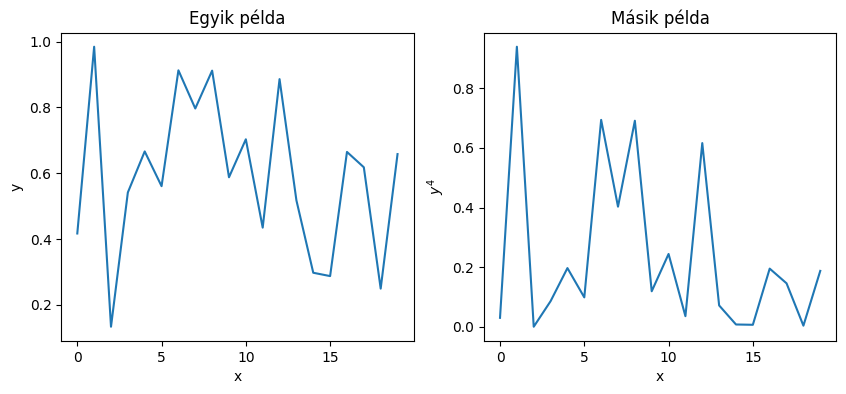

In [48]:
plt.figure(figsize = (10,4))

plt.subplot(1,2,1) # sorok száma, oszlopok száma, Hányadikba rajzolunk épp 1-es indextől, soronként halad balról
plt.plot(x, y )
plt.title('Egyik példa')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(1,2,2)
plt.plot(x, y**4 )
plt.title('Másik példa')
plt.xlabel('x')
plt.ylabel('$y^4$')

plt.show()

Ábrázoljuk az Anscombe kvartett tagjait egy 2×2-es ploton!

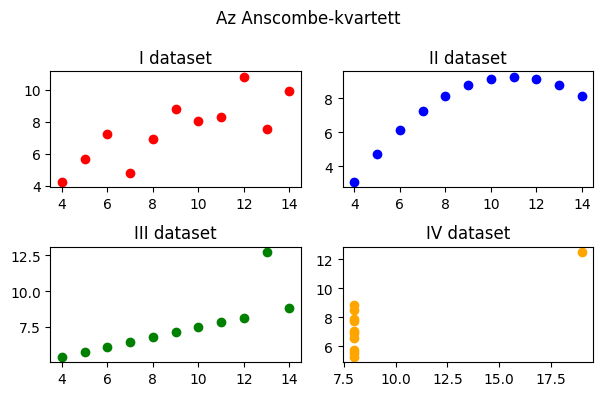

In [51]:
plt.figure(figsize = (6,4))
i = 0
colors = ['red', 'blue', 'green', 'orange']
for item in anscombe['dataset'].unique():
    i = i+1
    x = anscombe[ anscombe['dataset'] == item ]['x']
    y = anscombe[ anscombe['dataset'] == item ]['y']
    plt.subplot(2,2,i)
    plt.scatter(x,y, color=colors[i-1])
    plt.title(item + ' dataset')
    
plt.suptitle('Az Anscombe-kvartett') #főcím
plt.tight_layout(h_pad=1) # height padding
plt.show()

figures and axes

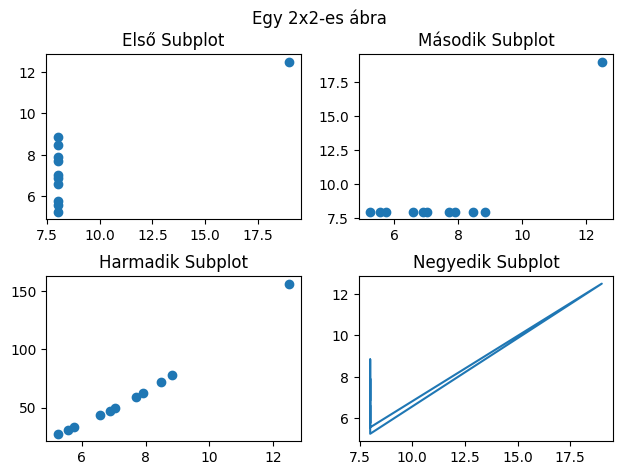

In [ ]:
fig, ax = plt.subplots(2, 2)

plt.suptitle('Egy 2x2-es ábra')
fig.tight_layout(h_pad=2)

#define subplot titles
ax[0, 0].set_title('Első Subplot')
ax[0, 1].set_title('Második Subplot')
ax[1, 0].set_title('Harmadik Subplot')
ax[1, 1].set_title('Negyedik Subplot')
ax[0,0].scatter(x,y)
ax[0,1].scatter(y,x)
ax[1,0].scatter(y,y**2)
ax[1,1].plot(x,y)

#display subplots 
plt.show()


Feladat:

    Készítsünk három ábrát, egymás mellett, melyek vizuális példát adnak arra, amikor pozitív, negatív, illetve közel nulla a korrelációs együttható értéke.
    Az ábrákon tüntessük fel a korrelációs együttható értékét 4 tizedesjegyre kerekítve.
    Minden alábrának adjunk címet és a teljes ábrának is.

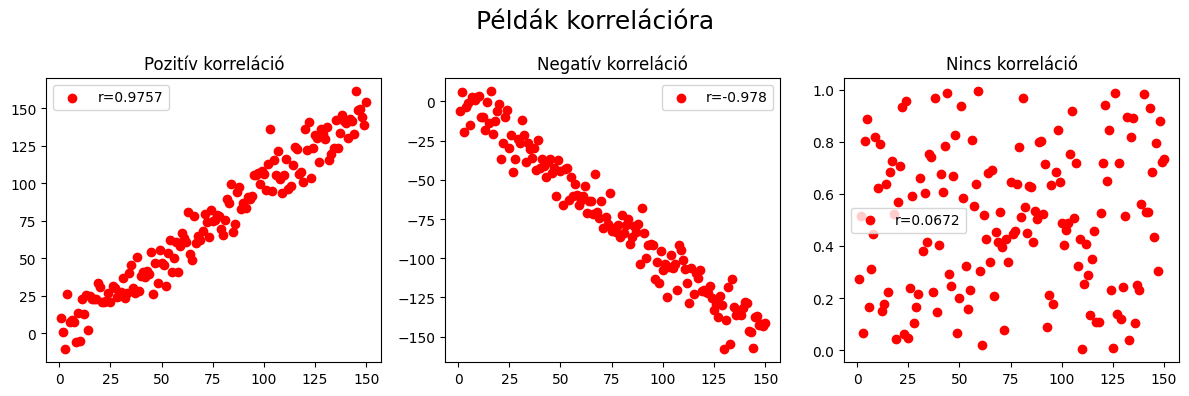

In [55]:
# Scatter plots and correlation:

fig, ax = plt.subplots(1,3, figsize = (12,4))

n= 150

x = np.arange(1,n+1) # 1-től n-ig egész számok, ez lesz a x tengely értéke
y1 = np.random.randn(n)*10 + x # normális eloszlású véletlen számok, szórás 10, és hozzáadjuk az x-et, így pozitív korreláció lesz
y2 = np.random.randn(n)*10 - x # normális eloszlású véletlen számok, szórás 10, és kivonjuk az x-et, így negatív korreláció lesz
y3 = np.random.random(n) # 0 és 1 közötti véletlen számok, így nem lesz korreláció az x-el

korr1 = np.corrcoef(x,y1)[0,1] # np.corrcoef() egy mátrixot ad vissza, ahol a [0,1] helyen van a x és y1 közötti korrelációs együttható
korr2 = np.corrcoef(x,y2)[0,1] # np.corrcoef() egy mátrixot ad vissza, ahol a [0,1] helyen van a x és y2 közötti korrelációs együttható
korr3 = np.corrcoef(x,y3)[0,1] # np.corrcoef() egy mátrixot ad vissza, ahol a [0,1] helyen van a x és y3 közötti korrelációs együttható

ax[0].scatter(x,y1, marker = 'o', color = 'r', label=f'r={korr1.round(4)}')
ax[0].set_title('Pozitív korreláció')
ax[0].legend()

ax[1].scatter(x,y2, marker = 'o', color = 'r', label=f'r={korr2.round(4)}')
ax[1].set_title('Negatív korreláció')
ax[1].legend()

ax[2].scatter(x,y3, marker = 'o', color = 'r', label=f'r={korr3.round(4)}')
ax[2].set_title('Nincs korreláció')
ax[2].legend()


plt.suptitle('Példák korrelációra', fontsize=18)
plt.tight_layout(h_pad=3)

plt.show()